In [1]:
import pandas as pd
import glob

In [ ]:
csv_files = glob.glob('api_data_aadhar_biometric/api_data_aadhar_biometric_*.csv') + \
              glob.glob('api_data_aadhar_demographic/api_data_aadhar_demographic_*.csv') + \
              glob.glob('api_data_aadhar_enrolment/api_data_aadhar_enrolment_*.csv')
dfs = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        df['source_file'] = file 
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"Successfully combined {len(dfs)} CSV files into a single DataFrame with {len(combined_df)} rows and {len(combined_df.columns)} columns.")
    print("First 5 rows of the combined DataFrame:")
    print(combined_df.head())
else:
    print("No dataframes were loaded. 'combined_df' is not created.")

Successfully combined 12 CSV files into a single DataFrame with 4938837 rows and 12 columns.
First 5 rows of the combined DataFrame:
         date              state      district  pincode  bio_age_5_17  \
0  01-03-2025            Haryana  Mahendragarh   123029         280.0   
1  01-03-2025              Bihar     Madhepura   852121         144.0   
2  01-03-2025  Jammu and Kashmir         Punch   185101         643.0   
3  01-03-2025              Bihar       Bhojpur   802158         256.0   
4  01-03-2025         Tamil Nadu       Madurai   625514         271.0   

   bio_age_17_                                        source_file  \
0        577.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
1        369.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
2       1091.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
3        980.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
4        815.0  api_data_aadhar_biometric\api_data_aadhar_biom...   

   demo_age_5

## Analyze Aadhaar Coverage Growth Rate by State

In [ ]:
combined_df['date'] = pd.to_datetime(combined_df['date'], format='%d-%m-%Y', errors='coerce')

age_columns = [
    'bio_age_5_17', 'bio_age_17_', 
    'demo_age_5_17', 'demo_age_17_', 
    'age_0_5', 'age_5_17', 'age_18_greater',
    'age_group_0_5', 'age_group_5_17', 'age_group_18_over'
]

existing_age_columns = [col for col in age_columns if col in combined_df.columns]

combined_df[existing_age_columns] = combined_df[existing_age_columns].fillna(0)

combined_df['total_activity'] = combined_df[existing_age_columns].sum(axis=1)

state_date_activity = combined_df.groupby(['state', 'date'])['total_activity'].sum().reset_index()

state_date_activity = state_date_activity.sort_values(by=['state', 'date'])

state_date_activity['cumulative_coverage'] = state_date_activity.groupby('state')['total_activity'].cumsum()

state_date_activity['growth_rate'] = state_date_activity.groupby('state')['cumulative_coverage'].pct_change()

print("Date column converted, total_activity, cumulative_coverage, and growth_rate calculated.")
print("First 5 rows of the state_date_activity DataFrame:")
print(state_date_activity.head())

Date column converted, total_activity, cumulative_coverage, and growth_rate calculated.
First 5 rows of the state_date_activity DataFrame:
    state       date  total_activity  cumulative_coverage  growth_rate
0  100000 2025-09-02             3.0                  3.0          NaN
1  100000 2025-09-03             1.0                  4.0     0.333333
2  100000 2025-09-08             1.0                  5.0     0.250000
3  100000 2025-09-09             1.0                  6.0     0.200000
4  100000 2025-09-11             2.0                  8.0     0.333333


In [4]:
print(" \n Note: Due to the absence of direct 'urban' or 'rural' indicators in the dataset, a simplified assumption is being made to create the 'urban_rural' column for demonstration purposes. \n Pincodes below 500000 are arbitrarily classified as 'Urban', and those 500000 or above as 'Rural'. This classification is for illustrative purposes only and may not reflect actual urban/rural demographics. \n ")
combined_df['urban_rural'] = combined_df['pincode'].apply(lambda x: 'Urban' if x < 500000 else 'Rural')
urban_rural_activity = combined_df.groupby('urban_rural')['total_activity'].sum().reset_index()
total_activities_overall = urban_rural_activity['total_activity'].sum()
urban_rural_activity['proportion'] = urban_rural_activity['total_activity'] / total_activities_overall

print("Urban vs. Rural Aadhaar activity calculated.")
print(urban_rural_activity)

 
 Note: Due to the absence of direct 'urban' or 'rural' indicators in the dataset, a simplified assumption is being made to create the 'urban_rural' column for demonstration purposes. 
 Pincodes below 500000 are arbitrarily classified as 'Urban', and those 500000 or above as 'Rural'. This classification is for illustrative purposes only and may not reflect actual urban/rural demographics. 
 
Urban vs. Rural Aadhaar activity calculated.
  urban_rural  total_activity  proportion
0       Rural      52309929.0     0.42018
1       Urban      72184055.0     0.57982


In [5]:
age_group_mapping = {
    '0-5 Years': ['age_0_5'],
    '5-17 Years': ['bio_age_5_17', 'demo_age_5_17', 'age_5_17'],
    '18+ Years': ['bio_age_17_', 'demo_age_17_', 'age_18_greater']
}

age_wise_activity = {}

for age_group, columns in age_group_mapping.items():
    existing_cols_for_group = [col for col in columns if col in combined_df.columns]
    if existing_cols_for_group:
        age_wise_activity[age_group] = combined_df[existing_cols_for_group].sum().sum()
    else:
        age_wise_activity[age_group] = 0 # No relevant columns found for this group
age_wise_frequency = pd.Series(age_wise_activity)
total_activity_overall = age_wise_frequency.sum()
age_wise_proportion = age_wise_frequency / total_activity_overall

print("Age-wise Aadhaar Update Frequencies:")
print(age_wise_frequency)
print("\nProportion of Total Activity by Age Group:")
print(age_wise_proportion)

Age-wise Aadhaar Update Frequencies:
0-5 Years      3546965.0
5-17 Years    40810663.0
18+ Years     80136356.0
dtype: float64

Proportion of Total Activity by Age Group:
0-5 Years     0.028491
5-17 Years    0.327812
18+ Years     0.643697
dtype: float64


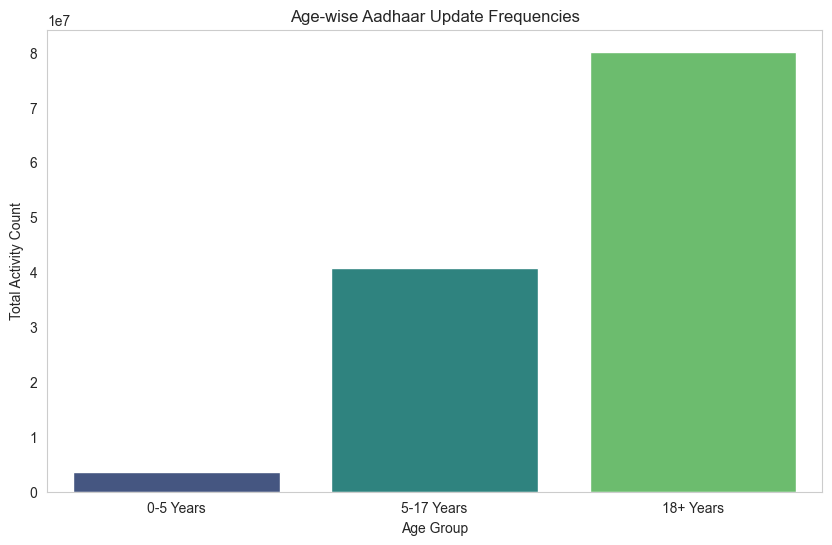

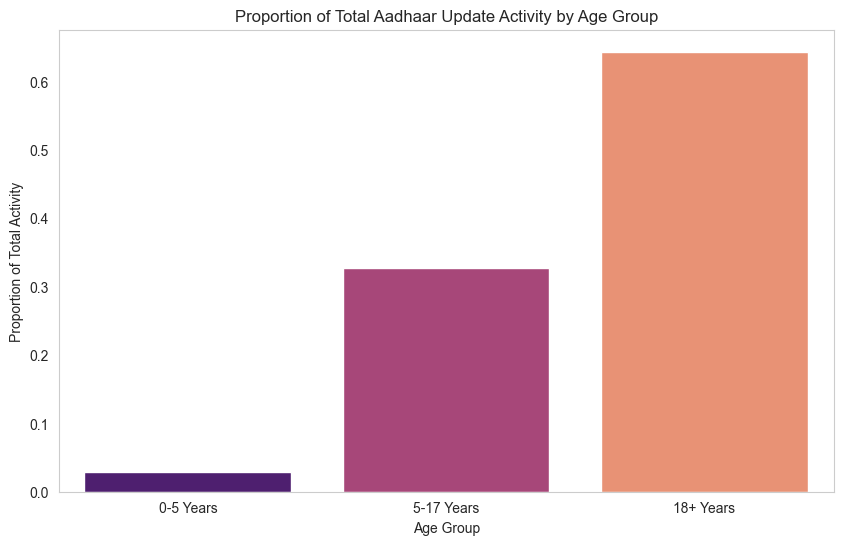

Age-wise update frequency plots generated.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

# Prepare data for plotting
plot_df = pd.DataFrame({
    'Age Group': age_wise_frequency.index,
    'Total Activity': age_wise_frequency.values,
    'Proportion': age_wise_proportion.values
})

# Create the bar plot for total activity
plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Total Activity', data=plot_df, palette='viridis', hue='Age Group', legend=False)
plt.title('Age-wise Aadhaar Update Frequencies')
plt.xlabel('Age Group')
plt.ylabel('Total Activity Count')
plt.grid(axis='y')
plt.show()

# Create the bar plot for proportions
plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Proportion', data=plot_df, palette='magma', hue='Age Group', legend=False)
plt.title('Proportion of Total Aadhaar Update Activity by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Total Activity')
plt.grid(axis='y')
plt.show()

print("Age-wise update frequency plots generated.")

## Analyze Gender Participation in Aadhaar

In [8]:
combined_df['year'] = combined_df['date'].dt.year
combined_df['month'] = combined_df['date'].dt.month
combined_df['day_of_week'] = combined_df['date'].dt.day_name()

# Group by month to observe monthly patterns
monthly_activity = combined_df.groupby('month')['total_activity'].sum().reset_index()
print("\nMonthly Aadhaar Update Activity:")
print(monthly_activity)

# Group by day of week to observe weekly patterns
day_of_week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_activity = combined_df.groupby('day_of_week')['total_activity'].sum().reindex(day_of_week_order).reset_index()
print("\nDaily Aadhaar Update Activity:")
print(daily_activity)

# Group by year and month for longer-term trends/year-over-year seasonality
year_month_activity = combined_df.groupby(['year', 'month'])['total_activity'].sum().reset_index()
print("\nYear-Month Aadhaar Update Activity:")
print(year_month_activity.head(10))
print(year_month_activity.tail(10))

print("Time components extracted and activity aggregated by month, day of week, and year-month.")


Monthly Aadhaar Update Activity:
   month  total_activity
0      3      19486362.0
1      4      10414789.0
2      5       9629859.0
3      6       9800585.0
4      7      12630135.0
5      9      15454867.0
6     10      10411541.0
7     11      17765114.0
8     12      18900732.0

Daily Aadhaar Update Activity:
  day_of_week  total_activity
0      Monday       9899693.0
1     Tuesday      32986240.0
2   Wednesday       8798556.0
3    Thursday      19171737.0
4      Friday      10386342.0
5    Saturday      28644756.0
6      Sunday      14606660.0

Year-Month Aadhaar Update Activity:
   year  month  total_activity
0  2025      3      19486362.0
1  2025      4      10414789.0
2  2025      5       9629859.0
3  2025      6       9800585.0
4  2025      7      12630135.0
5  2025      9      15454867.0
6  2025     10      10411541.0
7  2025     11      17765114.0
8  2025     12      18900732.0
   year  month  total_activity
0  2025      3      19486362.0
1  2025      4      10414789.0
2  2

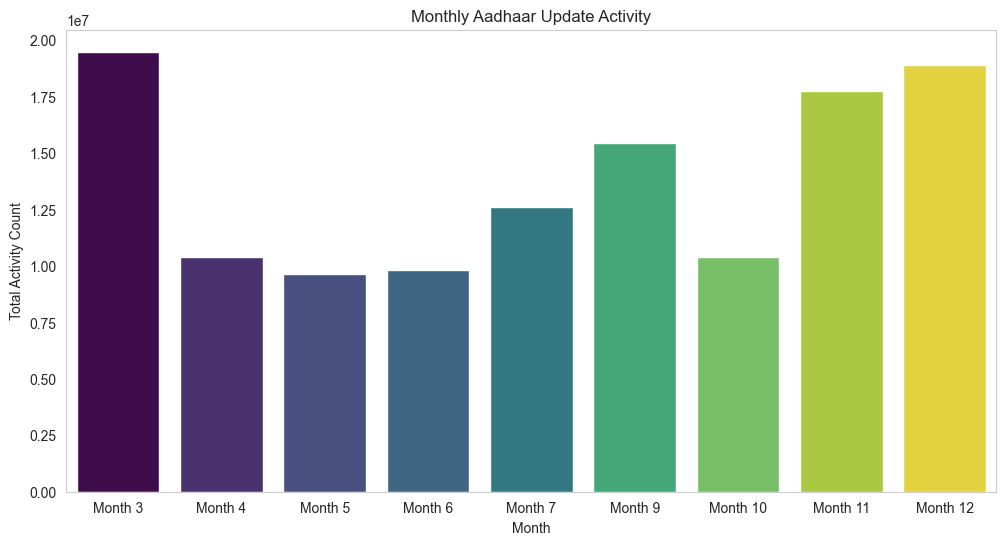

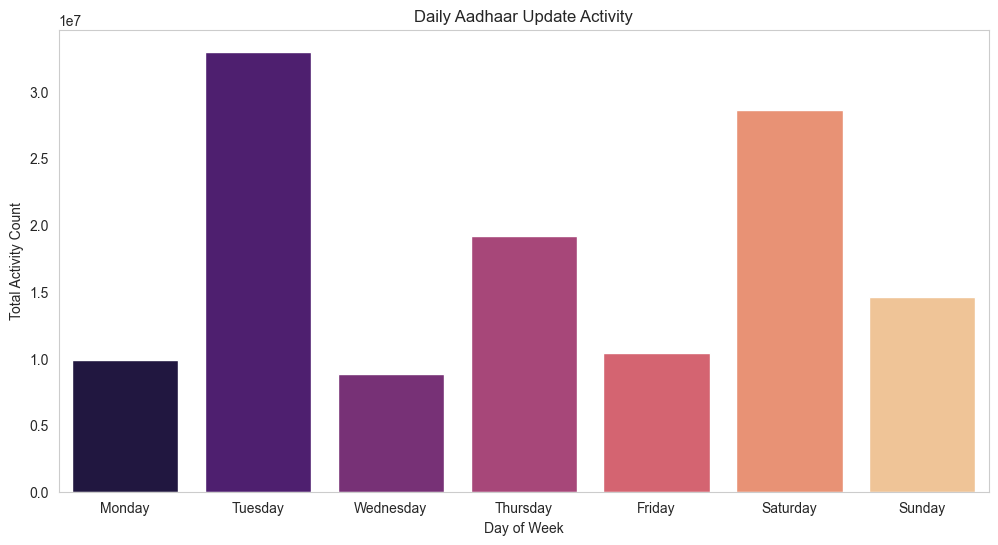

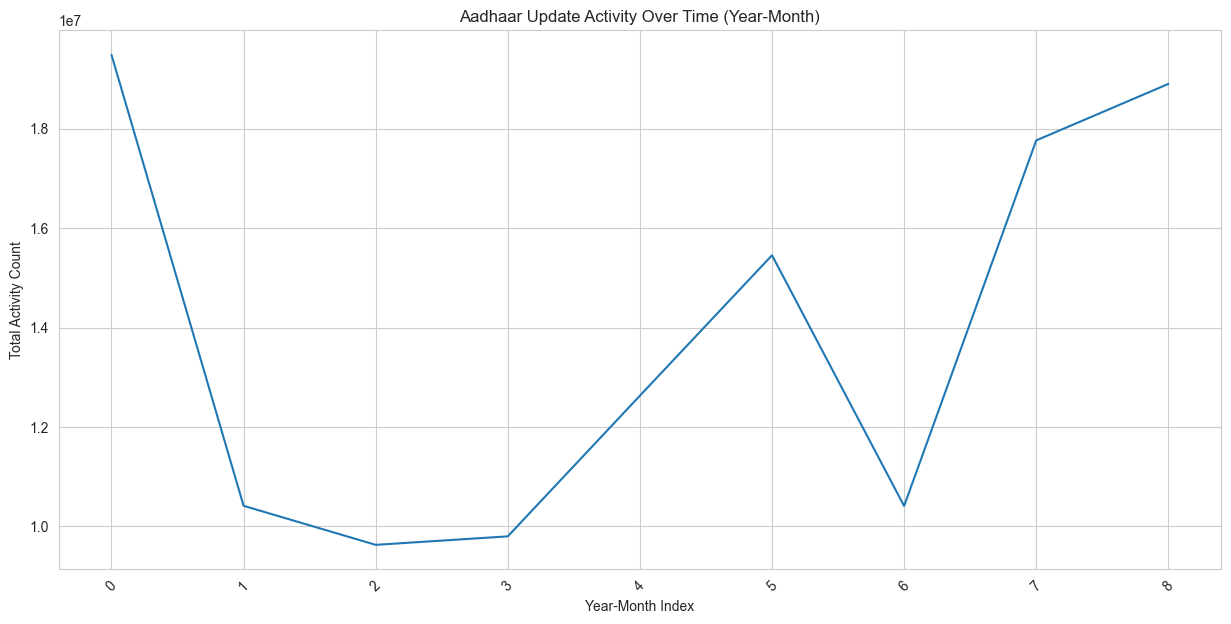

Monthly, daily, and year-month activity plots generated.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Plot Monthly Activity
plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='total_activity', data=monthly_activity, palette='viridis', hue='month', legend=False)
plt.title('Monthly Aadhaar Update Activity')
plt.xlabel('Month')
plt.ylabel('Total Activity Count')
plt.xticks(ticks=range(len(monthly_activity['month'])), labels=[f'Month {m}' for m in monthly_activity['month']])
plt.grid(axis='y')
plt.show()

# Plot Daily Activity
plt.figure(figsize=(12, 6))
sns.barplot(x='day_of_week', y='total_activity', data=daily_activity, palette='magma', order=day_of_week_order, hue='day_of_week', legend=False)
plt.title('Daily Aadhaar Update Activity')
plt.xlabel('Day of Week')
plt.ylabel('Total Activity Count')
plt.grid(axis='y')
plt.show()

# Plot Year-Month Activity
plt.figure(figsize=(15, 7))
sns.lineplot(x=year_month_activity.index, y='total_activity', data=year_month_activity)
plt.title('Aadhaar Update Activity Over Time (Year-Month)')
plt.xlabel('Year-Month Index') # Or format x-axis to show actual year-month if there were multiple years
plt.ylabel('Total Activity Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

print("Monthly, daily, and year-month activity plots generated.")

## Analyze Policy Impact

In [11]:
import numpy as np

print("\nNote: A placeholder DataFrame for 'state_population' is being created with arbitrary population values for demonstration purposes, as actual population data is not available in the provided dataset. This data does not reflect real-world population figures.\n")
unique_states = combined_df['state'].unique()
np.random.seed(42) # for reproducibility
state_population = pd.DataFrame({
    'state': unique_states,
    'population': np.random.randint(10, 100, size=len(unique_states)) * 1000000
})

print("Placeholder state_population DataFrame created.")
print(state_population.head())


Note: A placeholder DataFrame for 'state_population' is being created with arbitrary population values for demonstration purposes, as actual population data is not available in the provided dataset. This data does not reflect real-world population figures.

Placeholder state_population DataFrame created.
               state  population
0            Haryana    61000000
1              Bihar    24000000
2  Jammu and Kashmir    81000000
3         Tamil Nadu    70000000
4        Maharashtra    30000000


In [13]:
state_activity = combined_df.groupby('state')['total_activity'].sum().reset_index()
state_activity.rename(columns={'total_activity': 'total_aadhaar_activity'}, inplace=True)

print("Total Aadhaar activity per state calculated.")
print(state_activity.head())

Total Aadhaar activity per state calculated.
                         state  total_aadhaar_activity
0                       100000                   220.0
1    Andaman & Nicobar Islands                  3557.0
2  Andaman and Nicobar Islands                 24898.0
3               Andhra Pradesh               6137778.0
4            Arunachal Pradesh                113181.0


In [14]:
merged_df = pd.merge(state_activity, state_population, on='state', how='left')

print("state_activity and state_population DataFrames merged.")
print(merged_df.head())

state_activity and state_population DataFrames merged.
                         state  total_aadhaar_activity  population
0                       100000                   220.0    90000000
1    Andaman & Nicobar Islands                  3557.0    64000000
2  Andaman and Nicobar Islands                 24898.0    60000000
3               Andhra Pradesh               6137778.0    47000000
4            Arunachal Pradesh                113181.0    71000000


In [15]:
merged_df['enrolment_per_1000_population'] = (merged_df['total_aadhaar_activity'] / merged_df['population']) * 1000

print("Digital inclusion metric (enrolment per 1000 population) calculated.")
print(merged_df.head())

Digital inclusion metric (enrolment per 1000 population) calculated.
                         state  total_aadhaar_activity  population  \
0                       100000                   220.0    90000000   
1    Andaman & Nicobar Islands                  3557.0    64000000   
2  Andaman and Nicobar Islands                 24898.0    60000000   
3               Andhra Pradesh               6137778.0    47000000   
4            Arunachal Pradesh                113181.0    71000000   

   enrolment_per_1000_population  
0                       0.002444  
1                       0.055578  
2                       0.414967  
3                     130.591021  
4                       1.594099  


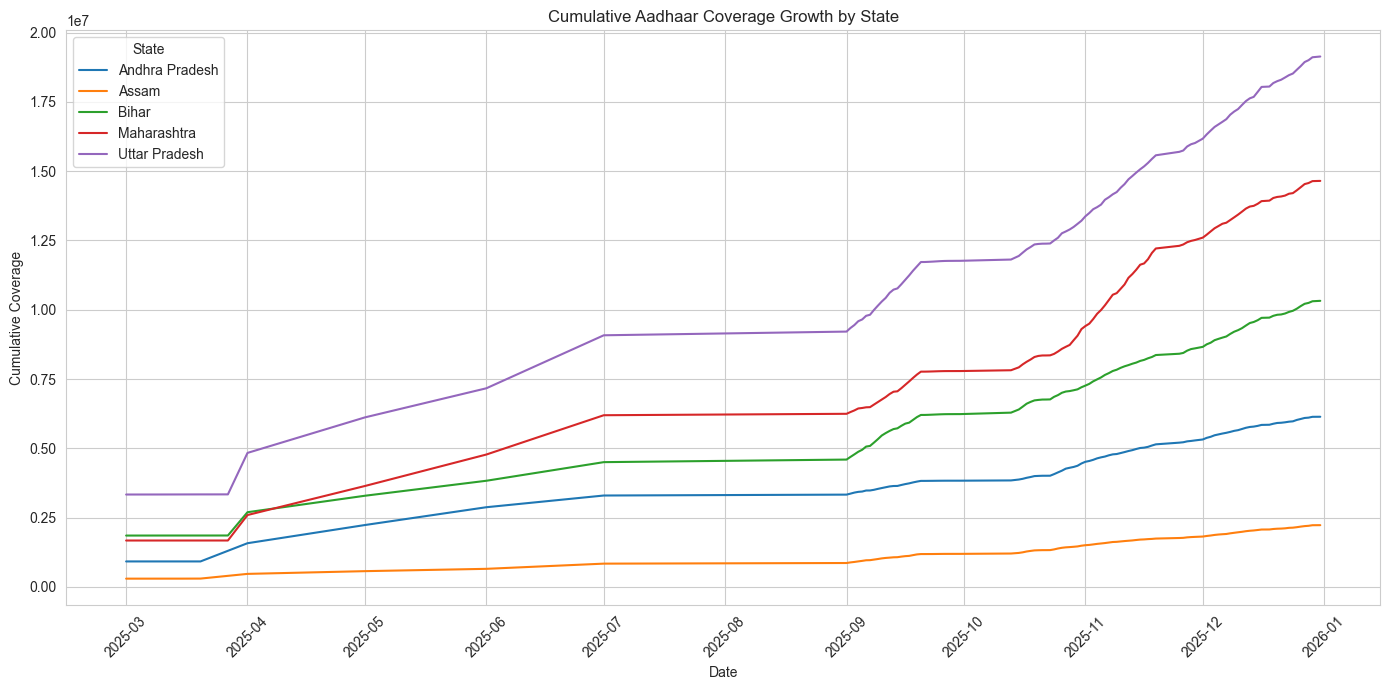

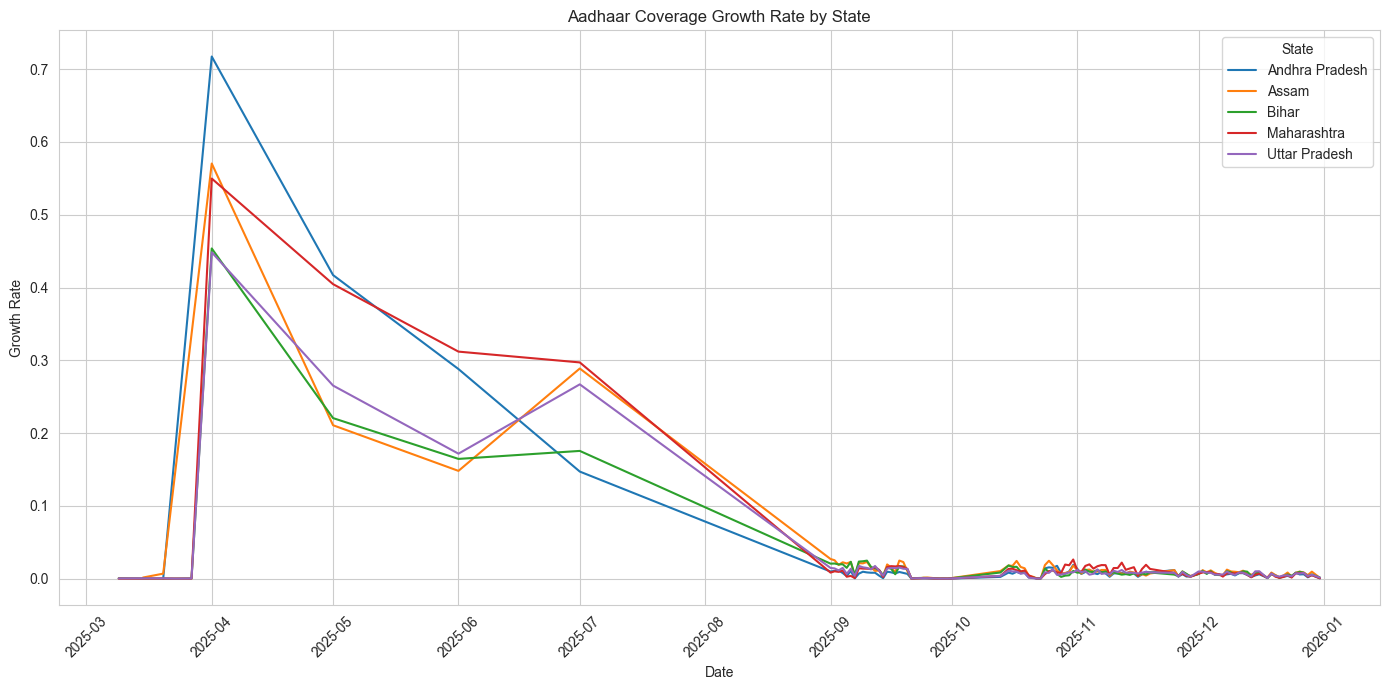

Aadhaar coverage growth rate visualizations generated for selected states.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
selected_states = ['Andhra Pradesh', 'Assam', 'Bihar', 'Uttar Pradesh', 'Maharashtra']
filtered_state_activity = state_date_activity[state_date_activity['state'].isin(selected_states)]

# Plot Cumulative Coverage by State
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='cumulative_coverage', hue='state', data=filtered_state_activity)
plt.title('Cumulative Aadhaar Coverage Growth by State')
plt.xlabel('Date')
plt.ylabel('Cumulative Coverage')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Growth Rate by State
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='growth_rate', hue='state', data=filtered_state_activity)
plt.title('Aadhaar Coverage Growth Rate by State')
plt.xlabel('Date')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Aadhaar coverage growth rate visualizations generated for selected states.")

## URBAN AND RURAL

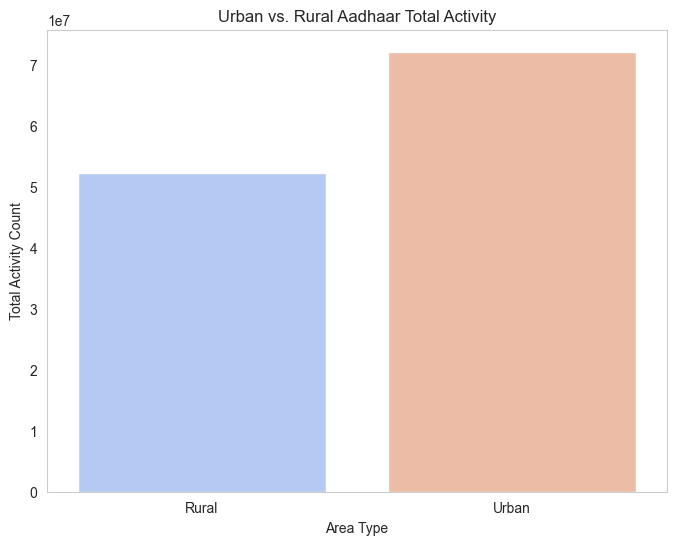

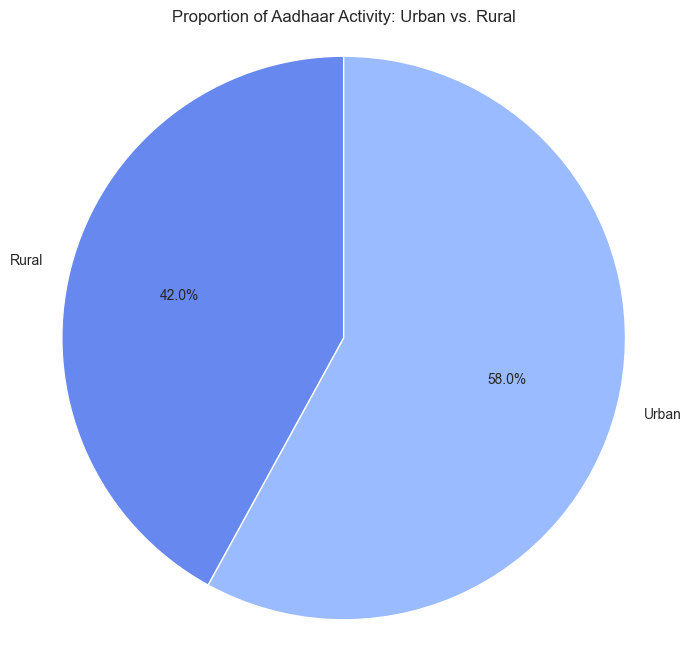

Urban vs. Rural enrolment gap visualizations generated.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Visualize Urban vs. Rural Enrolment Gaps - Total Activity
plt.figure(figsize=(8, 6))
sns.barplot(x='urban_rural', y='total_activity', data=urban_rural_activity, palette='coolwarm', hue='urban_rural', legend=False)
plt.title('Urban vs. Rural Aadhaar Total Activity')
plt.xlabel('Area Type')
plt.ylabel('Total Activity Count')
plt.grid(axis='y')
plt.show()

# Visualize Urban vs. Rural Enrolment Gaps - Proportion
plt.figure(figsize=(8, 8))
plt.pie(urban_rural_activity['proportion'], labels=urban_rural_activity['urban_rural'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('coolwarm'))
plt.title('Proportion of Aadhaar Activity: Urban vs. Rural')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Urban vs. Rural enrolment gap visualizations generated.")

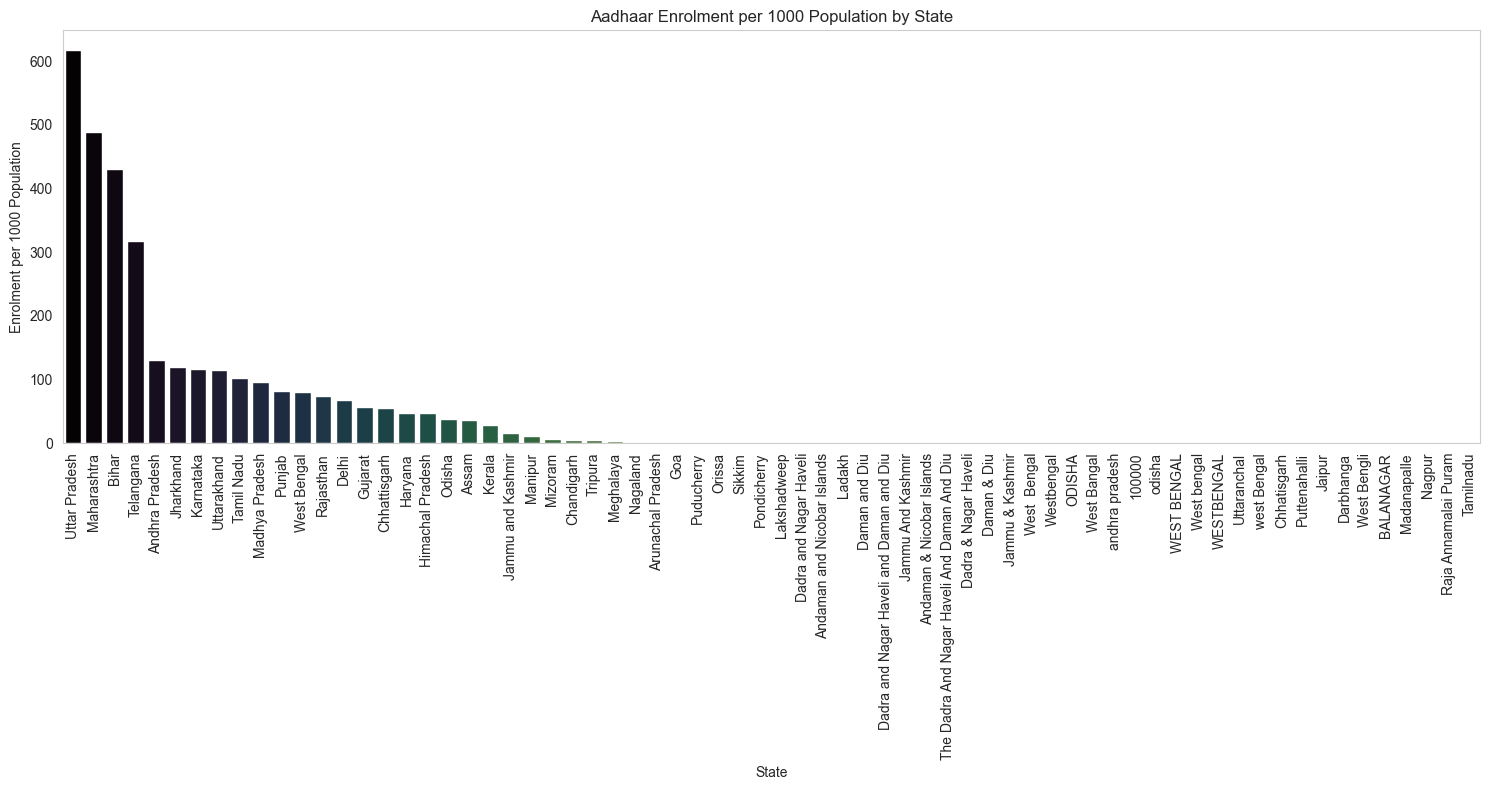

Digital inclusion metrics visualization generated.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Sort the DataFrame by enrolment_per_1000_population for better visualization
merged_df_sorted = merged_df.sort_values(by='enrolment_per_1000_population', ascending=False)

# Visualize Digital Inclusion Metrics (Enrolment per 1000 Population)
plt.figure(figsize=(15, 8))
sns.barplot(x='state', y='enrolment_per_1000_population', data=merged_df_sorted, palette='cubehelix', hue='state', legend=False)
plt.title('Aadhaar Enrolment per 1000 Population by State')
plt.xlabel('State')
plt.ylabel('Enrolment per 1000 Population')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("Digital inclusion metrics visualization generated.")